# ML renderer configuration reference

A renderer turns one source over one patch into an array, and the choice of
renderer sets the tensor structure everything downstream has to handle: whether
samples stack into a batch without padding, what appears when a source is
absent for a position and date, and how much of the native resolution
survives. Each configuration below states the structure it produces and what it
does with missing data.

The four renderers are `Resample`, which fixes the output grid, `Native`, which
keeps the source's own grid, `VectorPair`, which renders two components as one
field, and `Points`, which returns ragged records.

Every configuration runs against the same pinned catalog revision, the same
published eval QuerySet, and the same drawn row, so the differences between
them come from the rendering configuration alone.

This is a reference rather than a pipeline guide. For the end-to-end training
loader see the
[ML use cases notebook](spatio_temporal_query_generation.ipynb), and for
filters and coverage see the
[QuerySet and filter deep-dive](data_retrieval_workflows.ipynb).

In [1]:
import os
import warnings
from io import BytesIO
from pathlib import Path

from IPython.display import Image, display

# Hub transfers report progress on stderr, which would otherwise be captured as
# notebook output and rendered as noise in the documentation.
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

# Warnings raised by the library are part of what these tutorials demonstrate,
# but Python's default format prefixes each one with the absolute path of the
# file that raised it, which is an artifact of the machine that built the docs.
def _format_warning(message, category, filename, lineno, line=None):
    return f"{category.__name__}: {message}\n"

warnings.formatwarning = _format_warning

def display_figure(fig):
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=144, bbox_inches="tight")
    display(Image(data=buffer.getvalue()))

PATCH_SIZE_KM = 256          # the published patch size
REQUESTED_ROWS = 4
SEED = 7

# Draw records are notebook output, not cached data; they land beside the notebook.
DRAW_DIR = Path("draws")
DRAW_DIR.mkdir(exist_ok=True)

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# One diverging colormap across these tutorials, with an explicit range per
# source. RdBu_r centres its white on the midpoint of whatever range it is
# given, so leaving the range to autoscaling would move that centre between
# panels and make two figures of the same field look unalike.
CMAP = "RdBu_r"

# Ranges measured over drawn North Atlantic rows rather than taken from a
# product specification, so they bracket what these tutorials actually plot.
# A range far wider than one patch's own spread would flatten that patch to a
# single shade, so these are kept as tight as cross-panel comparison allows.
COLOR_RANGE = {
    "l4_sst": (20.0, 28.0),        # degrees celsius
    "l4_ssh": (-0.5, 0.5),         # metres
    "l3_swot": (-0.5, 0.5),        # metres
    "l3_ssh": (-0.5, 0.5),         # metres, nadir altimetry, same quantity as l3_swot
    "l4_sss": (32.0, 38.0),        # practical salinity units
    "velocity": (-0.8, 0.8),       # m/s, signed component, symmetric about zero
    "speed": (0.0, 0.8),           # m/s, a magnitude, so it starts at zero
    "argo_temp": (0.0, 30.0),      # degrees celsius
}

def color_limits(key):
    # Fall back to autoscaling for anything without a declared range.
    low, high = COLOR_RANGE.get(key, (None, None))
    return {"vmin": low, "vmax": high}

# Coastlines come from the Natural Earth shapefiles that ship with cartopy and
# are read from its local cache, so drawing them needs no network access while
# the notebooks execute. Only the geometries are used, not cartopy's projection
# machinery: these axes are already plain degrees, where PlateCarree is the
# identity, so the segments can go straight onto them.
import cartopy.io.shapereader as shpreader
from functools import lru_cache
from matplotlib.collections import LineCollection

@lru_cache(maxsize=None)
def _coastline_segments(resolution):
    path = shpreader.natural_earth(resolution=resolution, category="physical", name="coastline")
    segments = []
    for geometry in shpreader.Reader(path).geometries():
        parts = geometry.geoms if geometry.geom_type == "MultiLineString" else [geometry]
        segments.extend(np.asarray(part.coords) for part in parts)
    return tuple(segments)

def add_coastlines(axis, resolution=None, color="#444444", linewidth=.7, alpha=.85):
    # Draw continent contours on a plain longitude/latitude axis. The axis
    # limits must already be set, because they select both the detail level and
    # which segments are worth drawing.
    lon_min, lon_max = sorted(axis.get_xlim())
    lat_min, lat_max = sorted(axis.get_ylim())
    if resolution is None:
        # Coarser outlines suit a whole hemisphere and would look like a
        # polygon at patch scale, so the detail level follows the extent.
        span = max(lon_max - lon_min, lat_max - lat_min)
        resolution = "110m" if span > 60 else "50m" if span > 8 else "10m"
    visible = []
    for coords in _coastline_segments(resolution):
        lon, lat = coords[:, 0], coords[:, 1]
        if lat.max() < lat_min or lat.min() > lat_max:
            continue
        # Panels that run past +/-180 degrees see each landmass twice, so the
        # shifted copies are offered as well and the extent test drops them.
        for shift in (0.0, -360.0, 360.0):
            shifted = lon + shift
            if shifted.max() >= lon_min and shifted.min() <= lon_max:
                visible.append(np.column_stack([shifted, lat]))
    if visible:
        axis.add_collection(LineCollection(visible, colors=color, linewidths=linewidth,
                                           alpha=alpha, zorder=2.5))
    # A LineCollection would otherwise widen the limits to fit whole continents.
    axis.set_xlim(lon_min, lon_max)
    axis.set_ylim(lat_min, lat_max)
    return axis

def geographic_extent(record):
    # The (left, right, bottom, top) extent of a rendered record, in degrees.
    # Every gridded record carries the lon and lat vectors of the grid it was
    # rendered onto, so a panel can be drawn in degrees rather than in pixel
    # index and carry a coastline.
    lon = np.asarray(record["lon"]).ravel()
    lat = np.asarray(record["lat"]).ravel()
    return (float(lon.min()), float(lon.max()), float(lat.min()), float(lat.max()))

def batch_member(batch, token, index):
    # One sample's worth of a collated batch, in the shape the single-record
    # helpers above already accept. Collation stacks the grid vectors as
    # lat (B, H) and lon (B, W), so slicing the leading axis recovers the
    # record that geographic_extent and the imshow calls expect.
    stacked = batch[token]
    record = {key: stacked[key][index] for key in ("data", "valid_mask", "lat", "lon")
              if key in stacked}
    for key in ("source_valid", "support_mask", "spatial_padding_mask"):
        if key in stacked:
            record[key] = stacked[key][index]
    return record

def batch_panel_grid(batch, token, columns=4, day=0, title=None, panel_title=None,
                     figure_width=3.3, panel_height=3.0, show_coastlines=True):
    # A whole batch drawn as a grid of maps, one panel per batch member. Batch
    # size, not the caller, sets the number of panels, so a loader that returns
    # fewer rows than asked for still draws every row it did return.
    values = np.asarray(batch[token]["data"])
    count = values.shape[0]
    rows = int(np.ceil(count / columns))
    fig, axes = plt.subplots(rows, columns, squeeze=False,
                             figsize=(figure_width * columns, panel_height * rows),
                             constrained_layout=True)
    flat = axes.ravel()
    limits = color_limits(token)
    available = batch.get("availability", {}).get(token, [True] * count)
    drawn = None
    for index in range(count):
        axis, record = flat[index], batch_member(batch, token, index)
        axis.set(xticks=[], yticks=[])
        axis.set_title(panel_title(batch, index) if panel_title else f"row {index}", fontsize=9)
        extent = geographic_extent(record)
        if not available[index] or not np.isfinite(extent).all():
            # A row whose source has no asset for its date is rendered with no
            # grid at all, so there is nothing to place on a map. Saying so in
            # the panel keeps the batch's own geometry, where panel N is row N.
            axis.text(.5, .5, "no data\nfor this row", ha="center", va="center",
                      fontsize=9, color="#777777", transform=axis.transAxes)
            continue
        field = np.asarray(record["data"])[day]
        # Cells the renderer could not fill are left blank rather than drawn as
        # a value, so a sparse source reads as sparse.
        shown = np.where(np.asarray(record["valid_mask"])[day], field, np.nan)
        drawn = axis.imshow(shown, origin="lower", cmap=CMAP, interpolation="nearest",
                            aspect="auto", extent=extent, **limits)
        if show_coastlines:
            add_coastlines(axis)
    for axis in flat[count:]:
        axis.axis("off")
    if drawn is not None:
        fig.colorbar(drawn, ax=axes.ravel().tolist(), shrink=.6)
    if title:
        fig.suptitle(title)
    return fig

def batch_dates(batch):
    # The context start date of every member of a collated batch. Collation
    # keeps the per-sample query objects in a list, so the dates survive
    # batching and a panel can say which day it is showing.
    return [f"{spec.context.start:%Y-%m-%d}" for spec in batch["query"]]

In [3]:
from ocean_taco import CatalogConfig, QuerySet
from ocean_taco.retrieve import load_hf_dataset

config = CatalogConfig()
catalog = load_hf_dataset(config)
queryset = QuerySet.from_hub(PATCH_SIZE_KM, "eval")
print(f"queryset_id={queryset.queryset_id}; kind={queryset.header['kind']}; positions={len(queryset.positions)}; dates={len(queryset.dates)}")

queryset_id=2b55f024f45630d5a81546832a108ed99648c4d7b5024d79a21b1f0851ef4f18; kind=eval; positions=6027; dates=858


## The row every configuration uses

Every configuration below renders the same drawn row. Holding the row fixed
means any difference in the printed output comes from the renderer rather than
from the data. The helpers below print the tensor structure a configuration
produces and draw a rendered source: shapes, masks, and whether the source was
available at all.

The draw is conditioned on recorded SWOT and SSH coverage, so the shared row
carries the sparse source alongside the dense analyses and every panel below
has data to show. The [deep-dive](data_retrieval_workflows.ipynb) explains what
those requirements read.

In [4]:
from ocean_taco import CoverageRequirement, GeoBox, PatchSize, QueryFilter, draw_queryset, select_queryset
from ocean_taco.render import Native, Points, Resample, VectorPair
from ocean_taco.torch import OceanTACODataset

shared_draw = draw_queryset(queryset, requested_row_count=1, seed=29,
                            record_path=DRAW_DIR / "cookbook-draw.json",
                            query_filter=QueryFilter(box=GeoBox(-80, -30, 10, 45),
                                                     coverage=(CoverageRequirement("swot", "valid_fraction_ocean", 0.2),
                                                               CoverageRequirement("ssh", "valid_cells", 1))))
row = shared_draw.rows[0]
print(f"row: ({row['centre_lon']:.2f}, {row['centre_lat']:.2f}) on {row['anchor_time'][:10]}")

def render(sources):
    # Render the shared row under one configuration and report what came back.
    sample = OceanTACODataset(queries=shared_draw, sources=sources, catalog_config=config)[0]
    for token in sources:
        record, available = sample[token], sample["availability"][token]
        shape = tuple(np.asarray(record["data"]).shape)
        valid = int(np.asarray(record["valid_mask"]).sum())
        print(f"  {token:10s} data={str(shape):18s} available={str(available):5s} valid_cells={valid}")
    return sample

def show_grid(axis, record, title, component=None, key=None):
    # Draw a rendered source, or state its absence rather than inventing pixels.
    data = np.asarray(record["data"])
    if data.shape[0] == 0:
        axis.text(.5, .5, "structurally absent for\nthis position and date", ha="center", va="center", transform=axis.transAxes)
        axis.set(title=f"{title}: shape {data.shape}", xticks=[], yticks=[])
        return
    image = data[0] if component is None else data[0][component]
    # The record carries the grid it was rendered onto, so the panel is drawn in
    # degrees and can take a coastline instead of counting pixels.
    extent = geographic_extent(record)
    drawn = axis.imshow(image, origin="lower", cmap=CMAP, interpolation="nearest",
                        aspect="auto", extent=extent, **color_limits(key))
    axis.set(title=f"{title}: shape {data.shape}", xlabel="longitude [°]", ylabel="latitude [°]")
    add_coastlines(axis)
    axis.figure.colorbar(drawn, ax=axis, shrink=.8)

row: (-38.75, 41.45) on 2024-06-15


## `Resample`: fixed grids and multimodal fusion

`Resample((H, W), support_threshold)` puts every source on one grid, so each
becomes `(T, H, W)` with the same `H` and `W`, channels concatenate, and
batches stack without padding. The cost is interpolation, paid by every source
whose native grid differs from the target.

Fusion is the same configuration with another source added. Adding `l3_swot`
to two complete L4 fields exercises the sparse case: a swath either crosses
this patch on this date or it does not, and the output reports which.

`support_threshold` decides what happens when several native cells fall into
one output cell. Support is the fraction of the output cell backed by valid
source data, and cells below the threshold are marked invalid rather than
filled with an interpolated guess.

The 64x64 target used throughout this notebook sits above the native grid of
the dense L4 sources, which are about 23x31 and 19x24 cells over a 256 km
patch, so `Resample` warns once per token that it is upsampling. The warnings
below are expected and are kept visible rather than suppressed. A uniform
comparison grid keeps these configurations readable side by side, while
`native_shape` in each payload records the resolution the data actually
carries.

In [5]:
fixed = {"l4_sst": Resample((64, 64), .5), "l4_ssh": Resample((64, 64), .5)}
print("fixed grids:")
fixed_sample = render(fixed)
fusion = {**fixed, "l3_swot": Resample((64, 64), .5)}
print("with SWOT fused in:")
fusion_sample = render(fusion)

fixed grids:


  l4_sst     data=(1, 64, 64)        available=True  valid_cells=4096
  l4_ssh     data=(1, 64, 64)        available=True  valid_cells=4096
with SWOT fused in:


  l4_sst     data=(1, 64, 64)        available=True  valid_cells=4096
  l4_ssh     data=(1, 64, 64)        available=True  valid_cells=4096
  l3_swot    data=(1, 64, 64)        available=True  valid_cells=1718


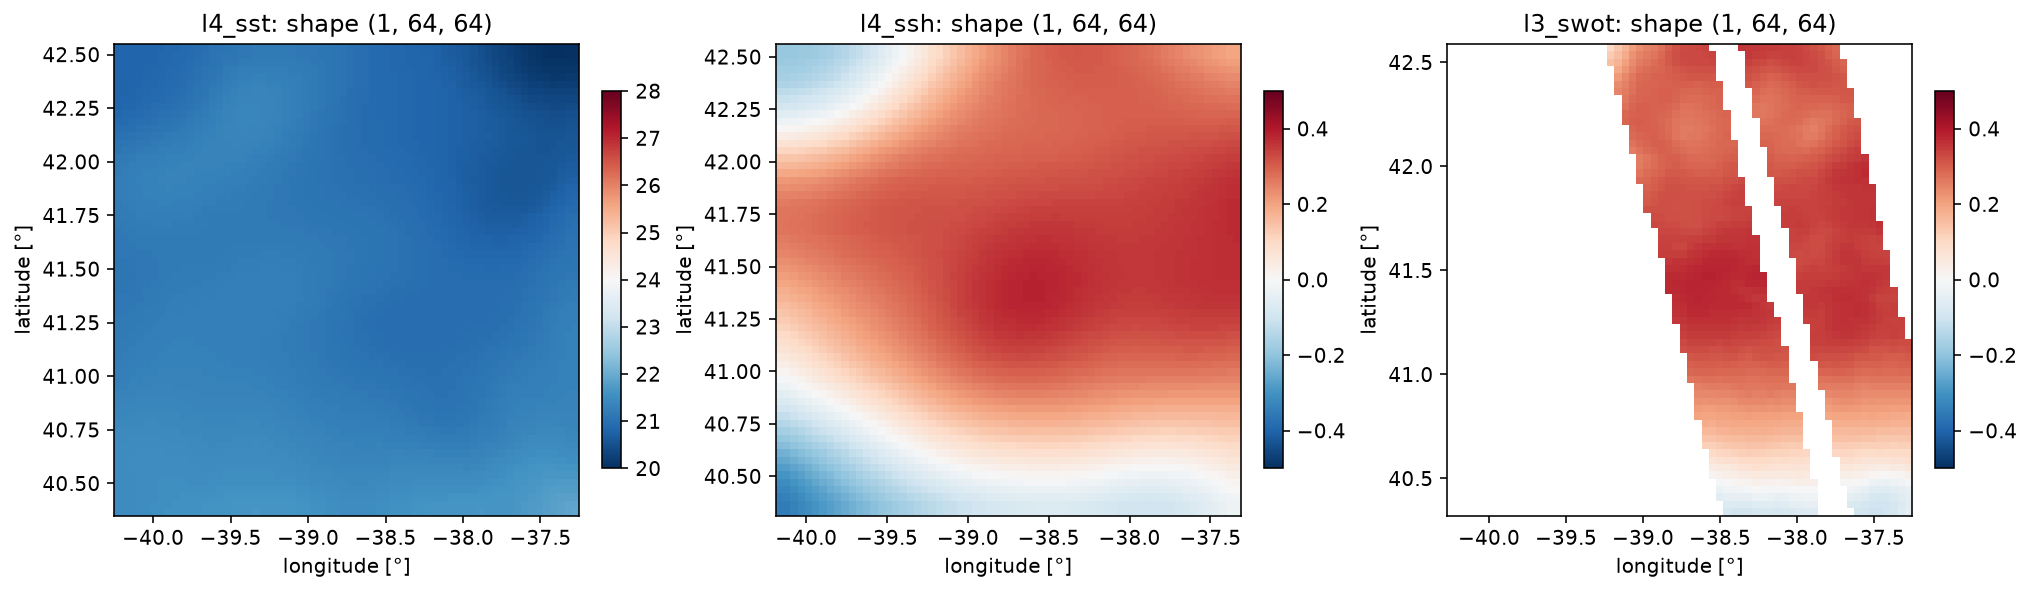

All three share one model-facing grid, and their masks stay separate.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
for axis, token in zip(axes, ("l4_sst", "l4_ssh", "l3_swot")):
    show_grid(axis, fusion_sample[token], token, key=token)
display_figure(fig)
print("All three share one model-facing grid, and their masks stay separate.")

## `VectorPair`: two components as one field

Rendered as independent sources, an eastward and a northward velocity
component can disagree about where they are valid: a cell ends up with a valid
`u` and an invalid `v`, which yields a direction no measurement supports.

`VectorPair` renders both components as a unit. The result is `(T, 2, H, W)`
rather than two `(T, H, W)` entries, `valid_mask` covers cells where **both**
components have support, and `pair_available` is the sample-level Boolean. The
two components come from the same underlying asset, so they are also fetched
once rather than twice.

In [7]:
vectors = {"velocity": VectorPair(Resample((64, 64), .5))}
print("components:", vectors["velocity"].components)
velocity_sample = render(vectors)
velocity = velocity_sample["velocity"]
data = np.asarray(velocity["data"])
if data.shape[0]:
    speed = np.hypot(data[0][0], data[0][1])
    print(f"u range=[{np.nanmin(data[:, 0]):.3f}, {np.nanmax(data[:, 0]):.3f}] m/s")
    print(f"v range=[{np.nanmin(data[:, 1]):.3f}, {np.nanmax(data[:, 1]):.3f}] m/s")
    print(f"speed max={np.nanmax(speed):.3f} m/s, pair_available={bool(velocity['pair_available'])}")

components: ('glorys_uo', 'glorys_vo')


  velocity   data=(1, 2, 64, 64)     available=True  valid_cells=4096
u range=[-0.704, 0.586] m/s
v range=[-0.413, 0.457] m/s
speed max=0.717 m/s, pair_available=True


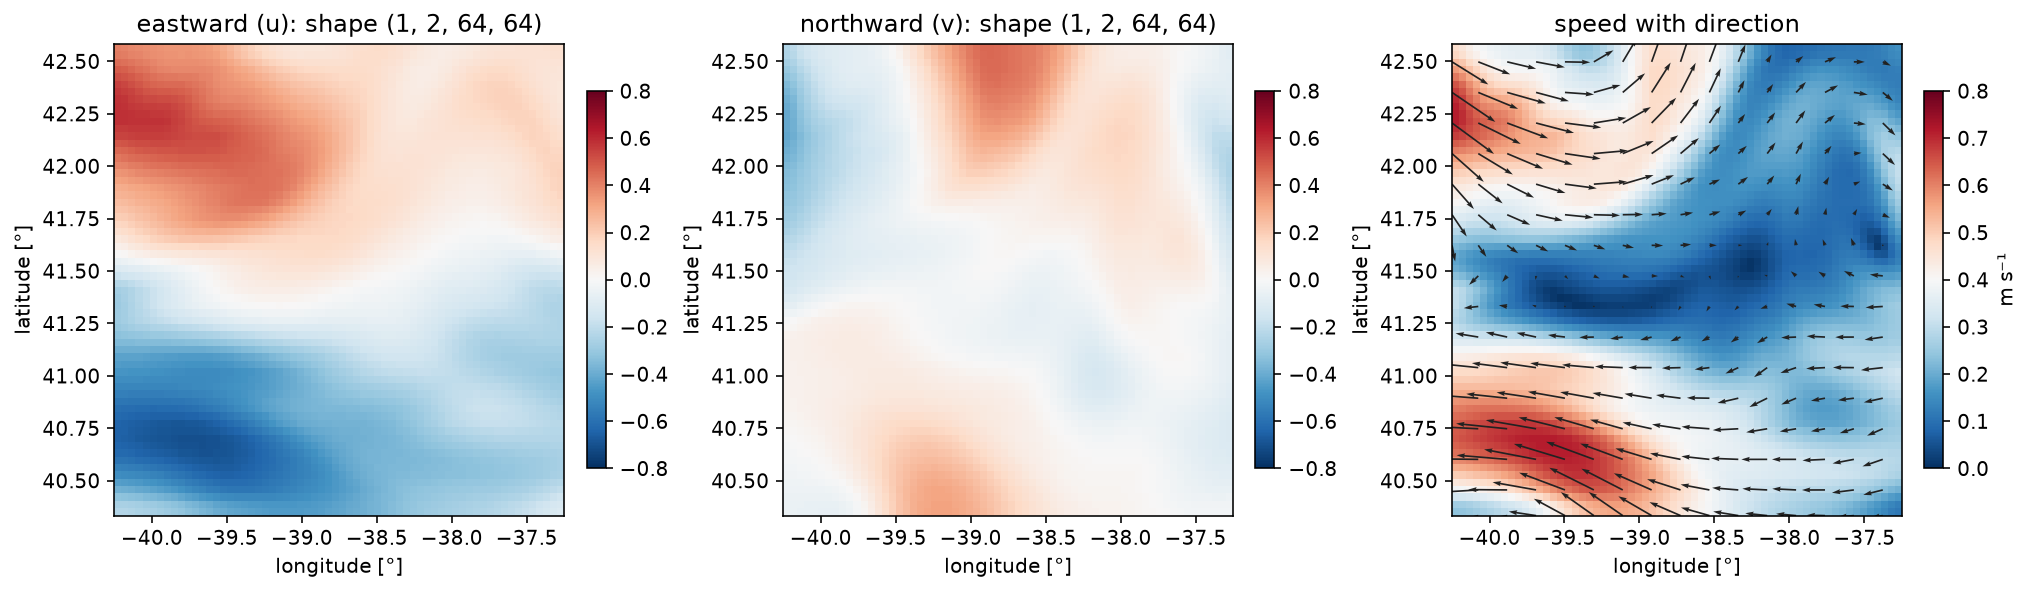

One shared mask governs both components, so every drawn arrow has support in each.


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
# The components are signed, so they get a range symmetric about zero, which
# puts the colormap's white at no flow. Speed is a magnitude and starts at zero.
show_grid(axes[0], velocity, "eastward (u)", component=0, key="velocity")
show_grid(axes[1], velocity, "northward (v)", component=1, key="velocity")
data = np.asarray(velocity["data"])
if data.shape[0]:
    speed = np.hypot(data[0][0], data[0][1])
    extent = geographic_extent(velocity)
    drawn = axes[2].imshow(speed, origin="lower", cmap=CMAP, interpolation="nearest",
                           aspect="auto", extent=extent, **color_limits("speed"))
    # The arrows are placed on the same degree axes as the image, so the quiver
    # grid is subsampled from the record's own longitude and latitude vectors.
    step = max(1, speed.shape[0] // 16)
    grid_x, grid_y = np.meshgrid(np.asarray(velocity["lon"]).ravel()[::step],
                                 np.asarray(velocity["lat"]).ravel()[::step])
    axes[2].quiver(grid_x, grid_y, data[0][0][::step, ::step], data[0][1][::step, ::step], color="#222222", scale=6)
    axes[2].set(title="speed with direction", xlabel="longitude [°]", ylabel="latitude [°]")
    add_coastlines(axes[2])
    fig.colorbar(drawn, ax=axes[2], shrink=.8, label="m s⁻¹")
else:
    axes[2].text(.5, .5, "pair unavailable", ha="center", va="center", transform=axes[2].transAxes)
display_figure(fig)
print("One shared mask governs both components, so every drawn arrow has support in each.")

## Sparse and dense sources in one configuration

**A missing SWOT cell records that the satellite did not sample there**, which
is the distinction that mixing a complete L4 analysis with a sparse L3 swath
has to preserve. A value cannot carry it, since zero is a perfectly plausible
sea-level anomaly. The masks carry it instead, so a model consuming both
sources should read `valid_mask` rather than testing values against a
sentinel, and a loss should be masked by it.

In [9]:
sparse_dense = {"l4_sst": Resample((64, 64), .5), "l3_swot": Resample((64, 64), .5)}
sparse_sample = render(sparse_dense)
for token in sparse_dense:
    mask = np.asarray(sparse_sample[token]["valid_mask"])
    if mask.size:
        print(f"{token:10s} valid fraction={mask.mean():.3f}")
print("A low valid fraction is evidence about sampling, not about the ocean.")

  l4_sst     data=(1, 64, 64)        available=True  valid_cells=4096
  l3_swot    data=(1, 64, 64)        available=True  valid_cells=1718
l4_sst     valid fraction=1.000
l3_swot    valid fraction=0.419
A low valid fraction is evidence about sampling, not about the ocean.


## `Points`: ragged Argo records

Argo measurements are float profiles at their own positions rather than a
field, so `Points` returns ragged records carrying coordinates and pressures
instead of a grid, and the count varies from row to row. Zero points is a valid
result and a valid batch member, because floats are sparse and most patches on
most days contain none.

`variable` selects which measurement to expose, and `pres_range` limits the
depth band in decibars. Omitting `pres_range` takes the shallowest usable level
per profile, while the configuration below asks for the top 200 dbar so a full
profile is visible.

The row rendered here comes from a draw conditioned on `profile_count`, which
is how to obtain a patch containing floats without naming coordinates by hand.
The survey cell after it measures how uncommon that is across an unconditioned
draw.

The left panel below carries a single marker because a float profiles where it
drifts, so all of its records share one position and differ in depth, which the
right panel resolves as a temperature profile. Across the unconditioned draw
surveyed above, one float in a 256 km patch is the ordinary count.

In [10]:
points = {"argo": Points(variable="TEMP", pres_range=(0, 200))}
argo_draw = draw_queryset(queryset, requested_row_count=1, seed=29,
                          record_path=DRAW_DIR / "argo-draw.json",
                          query_filter=QueryFilter(box=GeoBox(-80, -30, 10, 45),
                                                   coverage=(CoverageRequirement("argo", "profile_count", 1),)))
argo_row = argo_draw.rows[0]
print(f"row: ({argo_row['centre_lon']:.2f}, {argo_row['centre_lat']:.2f}) on {argo_row['anchor_time'][:10]}")
argo_sample = OceanTACODataset(queries=argo_draw, sources=points, catalog_config=config)[0]
record = argo_sample["argo"]
print("available:", argo_sample["availability"]["argo"])
for key in ("data", "lat", "lon", "pres"):
    if key in record:
        print(f"  {key:6s} shape={tuple(np.asarray(record[key]).shape)}")
print(f"{int(np.asarray(record['data']).size)} point records. The count is per patch and varies.")

row: (-58.15, 41.45) on 2023-08-25


available: True
  data   shape=(55,)
  lat    shape=(55,)
  lon    shape=(55,)
  pres   shape=(55,)
55 point records. The count is per patch and varies.


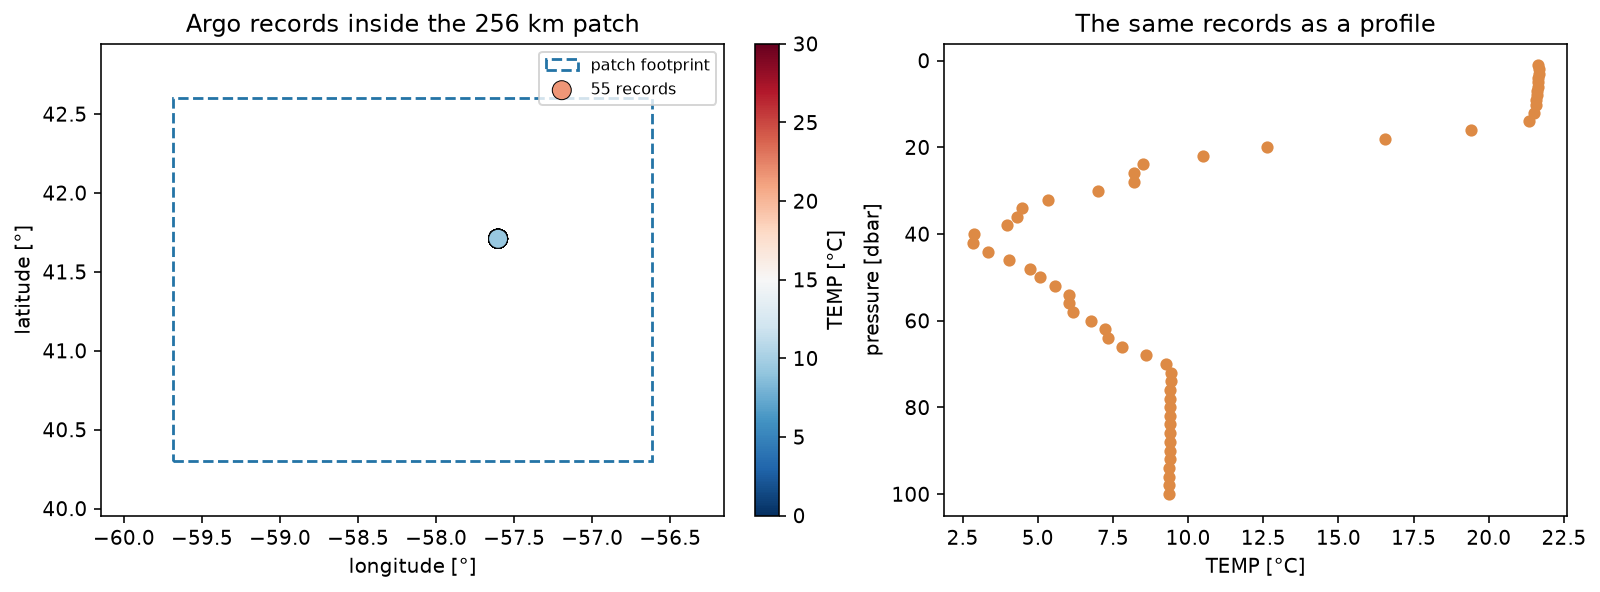

Points keep their own coordinates and pressures, and nothing is rasterised onto a grid.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
lon, lat = np.asarray(record.get("lon", [])), np.asarray(record.get("lat", []))
values = np.asarray(record["data"]).reshape(-1)
if lon.size:
    # Draw the patch footprint too. Every record here belongs to one float
    # profiling at a single location, so without the outline the panel would
    # read as a plotting failure rather than as genuine sparsity.
    lon_span, lat_span = PatchSize(PATCH_SIZE_KM, "km").to_degrees(centre_lat=argo_row["centre_lat"])
    axes[0].add_patch(plt.Rectangle((argo_row["centre_lon"] - lon_span / 2, argo_row["centre_lat"] - lat_span / 2),
                                    lon_span, lat_span, fill=False, edgecolor="#2474a6",
                                    linewidth=1.4, linestyle="--", label="patch footprint"))
    drawn = axes[0].scatter(lon, lat, c=values[:lon.size], s=90, cmap=CMAP, zorder=3,
                            edgecolor="black", linewidth=.5, label=f"{lon.size} records",
                            **color_limits("argo_temp"))
    fig.colorbar(drawn, ax=axes[0], label="TEMP [°C]")
    axes[0].legend(loc="upper right", fontsize=8)
    axes[0].set(xlim=(argo_row["centre_lon"] - lon_span * .65, argo_row["centre_lon"] + lon_span * .65),
                ylim=(argo_row["centre_lat"] - lat_span * .65, argo_row["centre_lat"] + lat_span * .65))
    add_coastlines(axes[0])
    pres = np.asarray(record["pres"]).reshape(-1)
    axes[1].scatter(values[:pres.size], pres, s=26, color="#dd8a45")
    axes[1].invert_yaxis()
    axes[1].set(title="The same records as a profile", xlabel="TEMP [°C]", ylabel="pressure [dbar]")
else:
    for axis in axes:
        axis.text(.5, .5, "no Argo profiles in this patch", ha="center", va="center", transform=axis.transAxes)
axes[0].set_title("Argo records inside the 256 km patch")
axes[0].set(xlabel="longitude [°]", ylabel="latitude [°]")
display_figure(fig)
print("Points keep their own coordinates and pressures, and nothing is rasterised onto a grid.")

In [12]:
# How often does an unconditioned draw contain floats at all?
survey = draw_queryset(queryset, requested_row_count=20, seed=29,
                       record_path=DRAW_DIR / "argo-survey-draw.json")
survey_dataset = OceanTACODataset(queries=survey, sources=points, catalog_config=config)
counts = [int(np.asarray(survey_dataset[index]["argo"]["data"]).size) for index in range(len(survey.rows))]
print(f"rows with at least one profile: {sum(count > 0 for count in counts)} of {len(counts)}")
print("Zero is the ordinary case at this patch size, which is why the configuration above conditions its draw.")

rows with at least one profile: 1 of 20
Zero is the ordinary case at this patch size, which is why the configuration above conditions its draw.


## `Native`: the source grid, and bucketing

Where `Resample` pays interpolation for a uniform grid, `Native()` keeps the
source's own grid, so no cell is interpolated or invented. Shapes then vary
from row to row, and varying shapes cannot be stacked. `ShapeBucketSampler` handles that by grouping rows whose native
shapes already agree, so each batch is internally uniform without padding.

Pass `shuffle=False` for a reproducible bucket ordering, since it shuffles
within and across buckets by default and a printed bucket list would otherwise
depend on the seed. The
[ML use cases notebook](spatio_temporal_query_generation.ipynb) runs this
sampler against a real `DataLoader`.

In [13]:
native_sample = render({"l3_swot": Native()})
resampled = np.asarray(fusion_sample["l3_swot"]["data"])
native = np.asarray(native_sample["l3_swot"]["data"])
print(f"native shape={native.shape}, resampled shape={resampled.shape}")
print("Native preserves the source grid exactly. Resample fixes the shape and pays interpolation for it.")

  l3_swot    data=(1, 128, 121)      available=True  valid_cells=6271
native shape=(1, 128, 121), resampled shape=(1, 64, 64)
Native preserves the source grid exactly. Resample fixes the shape and pays interpolation for it.


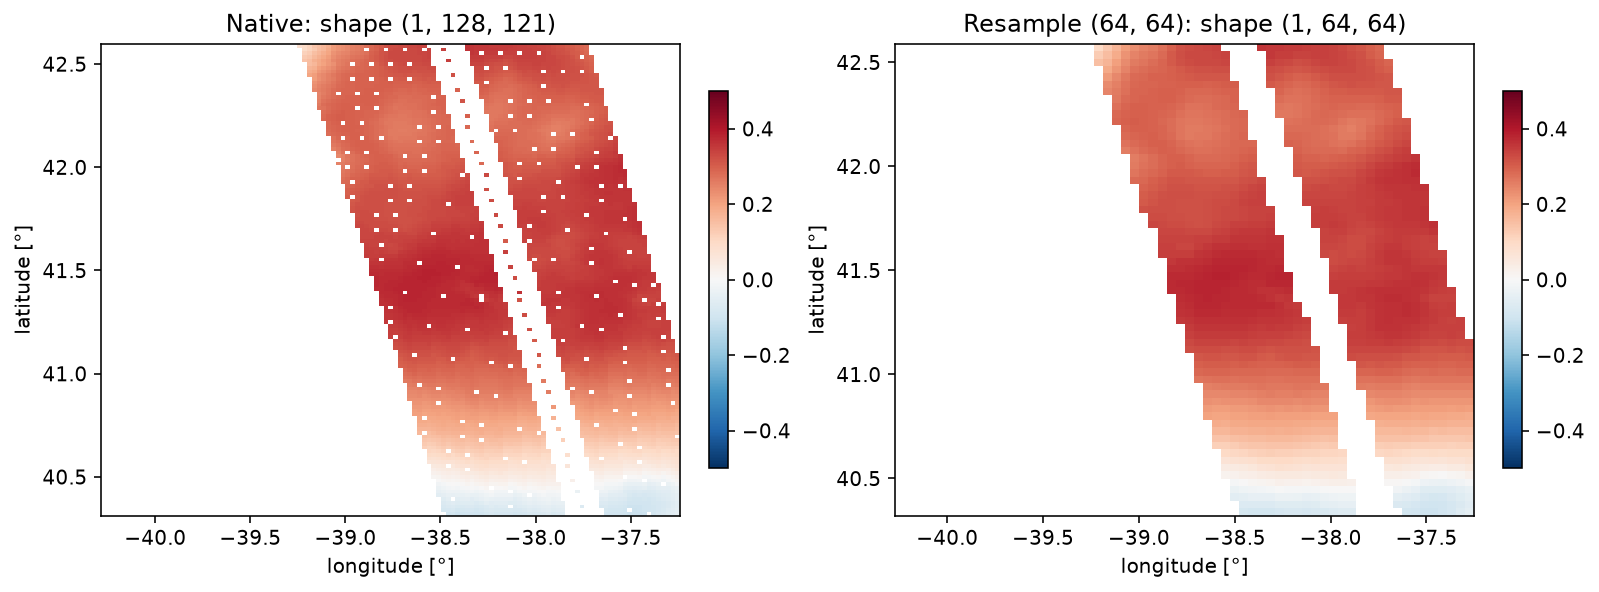

Same row and same colour range, so the difference between the panels is resolution alone.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
show_grid(axes[0], native_sample["l3_swot"], "Native", key="l3_swot")
show_grid(axes[1], fusion_sample["l3_swot"], "Resample (64, 64)", key="l3_swot")
display_figure(fig)
print("Same row and same colour range, so the difference between the panels is resolution alone.")

In [15]:
from ocean_taco.torch import ShapeBucketSampler
shapes = [(32, 48), (32, 48), (40, 48), (40, 48), (32, 48)]
sampler = ShapeBucketSampler(shapes, batch_size=2, seed=19, shuffle=False)
batches = list(sampler)
print("native shapes:", shapes)
print("batches:", batches)
for batch in batches:
    print("  ", [shapes[index] for index in batch], "-> uniform:", len({shapes[index] for index in batch}) == 1)

native shapes: [(32, 48), (32, 48), (40, 48), (40, 48), (32, 48)]
batches: [[0, 1], [4], [2, 3]]
   [(32, 48), (32, 48)] -> uniform: True
   [(32, 48)] -> uniform: True
   [(40, 48), (40, 48)] -> uniform: True


## Regional and antimeridian boxes

A regional box resolves to a single segment. A box crossing the antimeridian
resolves to two, because a single interval from 170 to −170 would be either
empty or global depending on which comparison ran first. Splitting it keeps
every downstream test a simple interval comparison, and the
[deep-dive](data_retrieval_workflows.ipynb) plots the geometry.

In [16]:
regional = GeoBox(-80, -30, 10, 45)
wrapped = GeoBox(170, -170, 10, 30, wraps_antimeridian=True)
print("regional segments:", len(regional.segments()))
for segment in wrapped.segments():
    print("  wrapped segment:", segment.to_dict())
print(f"regional selection: {select_queryset(queryset, QueryFilter(box=regional)).count:,} pairs")

regional segments: 1
  wrapped segment: {'lon_min': 170, 'lon_max': 180.0, 'lat_min': 10, 'lat_max': 30, 'wraps_antimeridian': False}
  wrapped segment: {'lon_min': -180.0, 'lon_max': -170, 'lat_min': 10, 'lat_max': 30, 'wraps_antimeridian': False}
regional selection: 290,862 pairs


## Normalisation

Normalisation belongs to the experiment, not to the loader, and has to be
recorded alongside it. The loader therefore returns decoded values in their
recorded units and normalises nothing. Apply it through `valid_mask` so that
invalid cells stay NaN rather than becoming a plausible-looking zero, and
compute the statistics once over the training rows rather than per batch.

`l3_swot` is the informative source here, since its swath covers only part of
the patch, so the mask genuinely excludes cells and the NaN behaviour is
visible. The comparison at the end comes out differently under zero-filling,
which treats every unobserved cell as a measured zero and so biases the mean
towards zero.

In [17]:
import torch
def normalise_valid(data, mask, mean, std):
    output = torch.full_like(data, float("nan"))
    output[mask] = (data[mask] - mean) / torch.as_tensor(std, dtype=data.dtype).clamp_min(1e-6)
    return output

values, mask = fusion_sample["l3_swot"]["data"], fusion_sample["l3_swot"]["valid_mask"]
mean, std = values[mask].mean(), values[mask].std()
normalised = normalise_valid(values, mask, mean, std)
print(f"source mean={mean:.4f} std={std:.4f} over {int(mask.sum())} of {mask.numel()} cells")
print(f"normalised mean={normalised[mask].mean():.3e} std={normalised[mask].std():.3f}")
print(f"{int((~mask).sum())} invalid cells, all still NaN: {bool(torch.isnan(normalised[~mask]).all())}")
filled = torch.nan_to_num(values, nan=0.0)
print(f"masked mean={mean:.4f} against zero-filled mean={filled.mean():.4f}")

source mean=0.2664 std=0.1126 over 1718 of 4096 cells
normalised mean=1.840e-07 std=1.000
2378 invalid cells, all still NaN: True
masked mean=0.2664 against zero-filled mean=0.1117
